<a href="https://colab.research.google.com/github/pande17827/FastApi/blob/main/9.improving%20the%20fastApi%20Api/1.introudction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("HEllo")

![CampusX - Improving the FastAPI API Video 8 CampusX [M17qwKnmG38 - 1536x864 - 34m32s].png](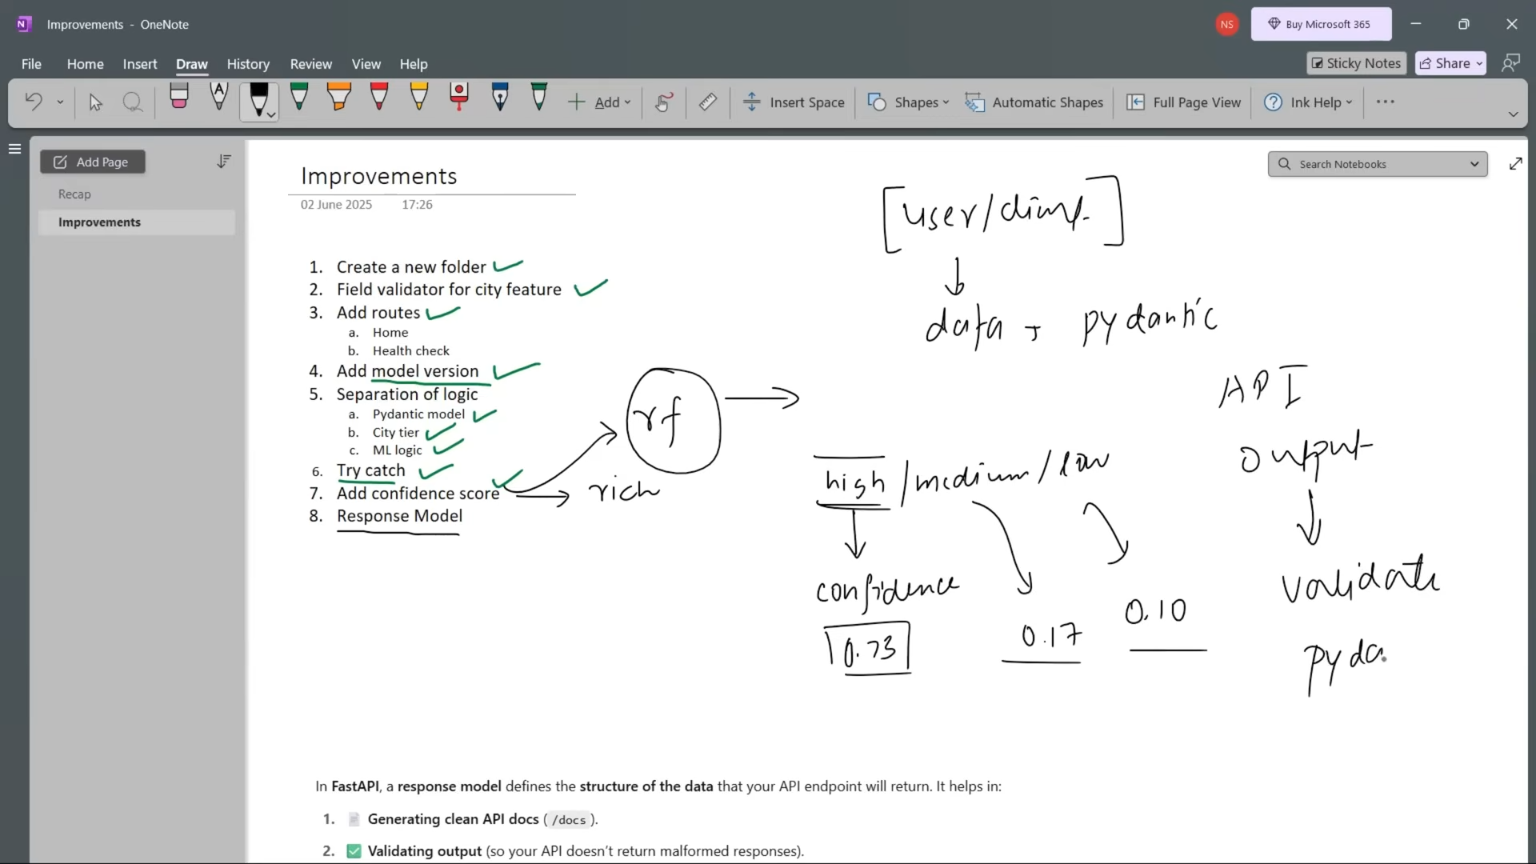)

![CampusX - Improving the FastAPI API Video 8 CampusX [M17qwKnmG38 - 1536x864 - 35m39s].png](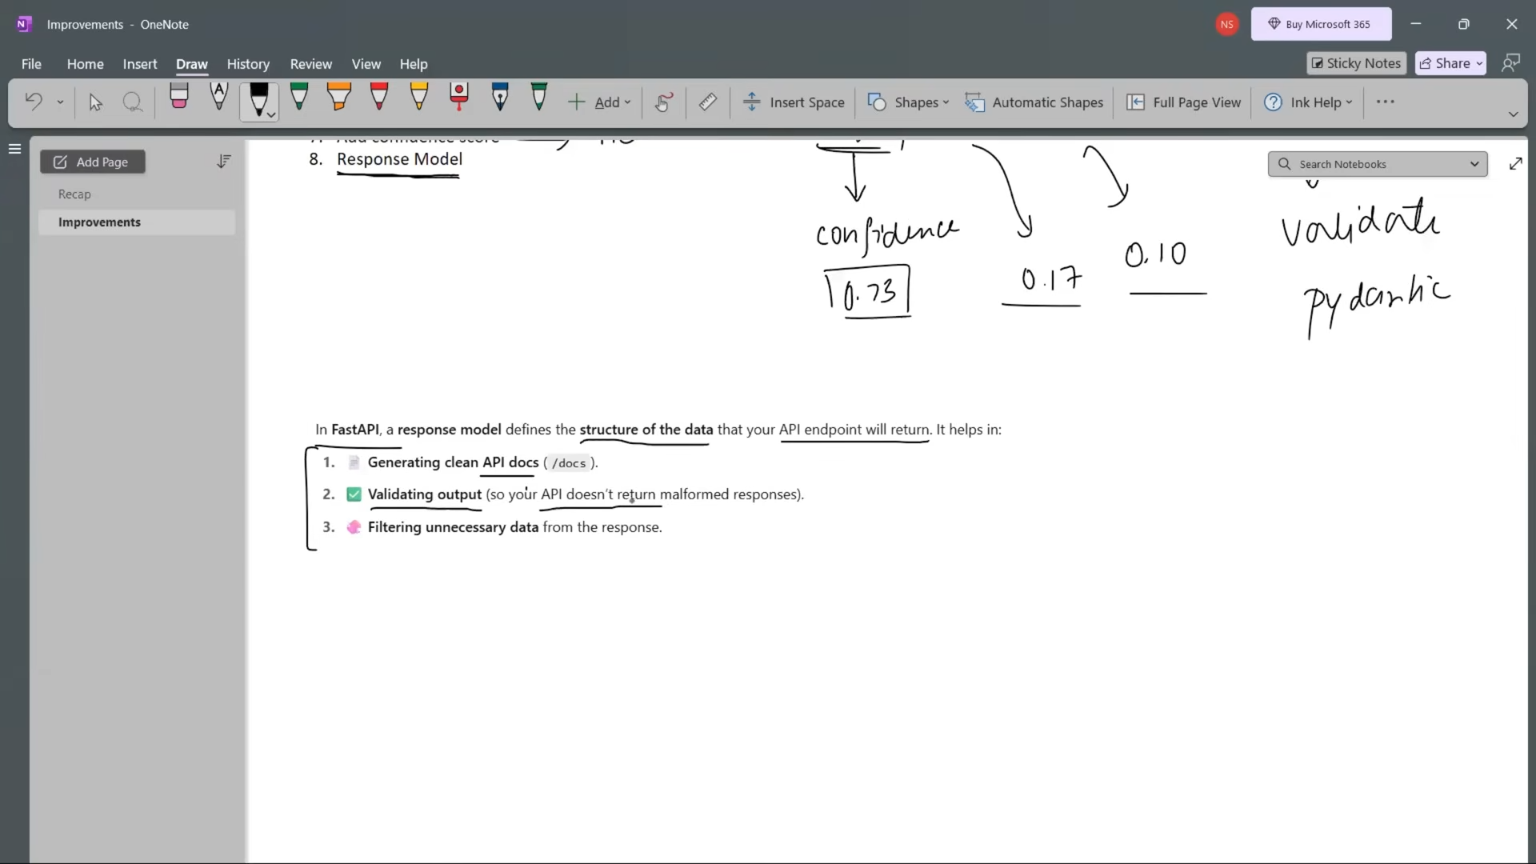)

# <b> Improvent0:-create a sepearate folder for new project

# <b>Improvement1:-Storing Models in seperate folder

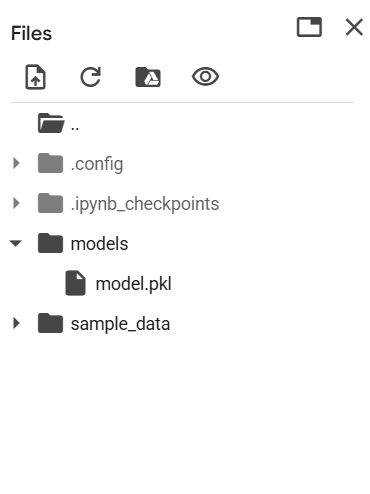

# <b>Improvement2:-Filed Validator for city field

we will define a @filed_validator that will validate the city filed than will distinguish btw tier1 city and other by capitializing the tier1 city

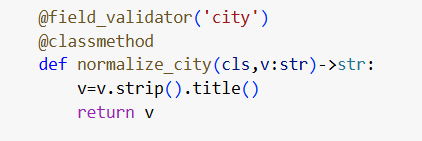

In [ ]:

!pip install fastapi uvicorn pydantic nest-asyncio pyngrok


In [ ]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field, computed_field,field_validator
from typing import Literal, Annotated
import pickle
import pandas as pd
from google.colab import userdata
from pyngrok import ngrok
import nest_asyncio
import uvicorn



# setting ngrok
ngrok_auth_token = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_auth_token)

# import the ml model
with open('/content/models/model.pkl', 'rb') as f:
    model = pickle.load(f)

app = FastAPI()

tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

# pydantic model to validate incoming data
class UserInput(BaseModel):

    age: Annotated[int, Field(..., gt=0, lt=120, description='Age of the user')]
    weight: Annotated[float, Field(..., gt=0, description='Weight of the user')]
    height: Annotated[float, Field(..., gt=0, lt=2.5, description='Height of the user')]
    income_lpa: Annotated[float, Field(..., gt=0, description='Annual salary of the user in lpa')]
    smoker: Annotated[bool, Field(..., description='Is user a smoker')]
    city: Annotated[str, Field(..., description='The city that the user belongs to')]
    occupation: Annotated[Literal['retired', 'freelancer', 'student', 'government_job',
       'business_owner', 'unemployed', 'private_job'], Field(..., description='Occupation of the user')]

    @computed_field
    @property
    def bmi(self) -> float:
        return self.weight/(self.height**2)

    @computed_field
    @property
    def lifestyle_risk(self) -> str:
        if self.smoker and self.bmi > 30:
            return "high"
        elif self.smoker or self.bmi > 27:
            return "medium"
        else:
            return "low"

    @computed_field
    @property
    def age_group(self) -> str:
        if self.age < 25:
            return "young"
        elif self.age < 45:
            return "adult"
        elif self.age < 60:
            return "middle_aged"
        return "senior"

    @computed_field
    @property
    def city_tier(self) -> int:
        if self.city in tier_1_cities:
            return 1
        elif self.city in tier_2_cities:
            return 2
        else:
            return 3

    @field_validator('city')
    @classmethod
    def normalize_city(cls,v:str)->str:
        v=v.strip().title()
        return v

@app.post('/predict')
def predict_premium(data: UserInput):

    input_df = pd.DataFrame([{
        'bmi': data.bmi,
        'age_group': data.age_group,
        'lifestyle_risk': data.lifestyle_risk,
        'city_tier': data.city_tier,
        'income_lpa': data.income_lpa,
        'occupation': data.occupation
    }])

    prediction = model.predict(input_df)[0]

    return JSONResponse(status_code=200, content={'predicted_category': prediction})


# Apply nest_asyncio to allow running uvicorn inside notebook
nest_asyncio.apply()

# Open an ngrok tunnel to the default uvicorn port 8000
public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")

# Run the FastAPI app
uvicorn.run(app, host="0.0.0.0", port=8000)





Public URL: NgrokTunnel: "https://ecd7-35-188-224-168.ngrok-free.app" -> "http://localhost:8000"


INFO:     Started server process [403]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2402:a00:405:d365:2dba:2:95:6eaf:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     2402:a00:405:d365:2dba:2:95:6eaf:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [403]


# <b>Improvement2:-Adding Routes

 <b>improvement2.1:- Home Routes("human will get the idea whther your api is working or not"

without Home Routes it will look something like this which give bad impression

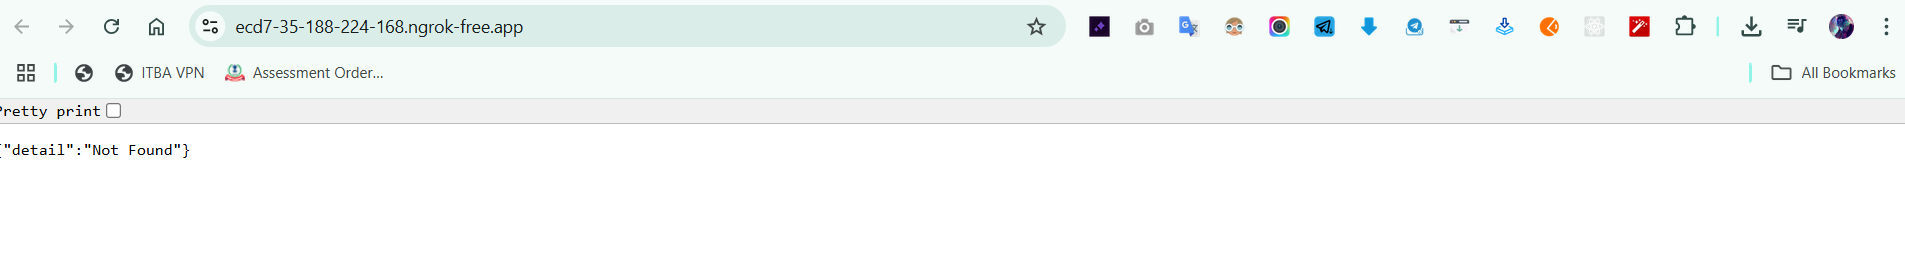

therefore we will create a routes for HomePage know as Home

In [ ]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field, computed_field,field_validator
from typing import Literal, Annotated
import pickle
import pandas as pd
from google.colab import userdata
from pyngrok import ngrok
import nest_asyncio
import uvicorn



# setting ngrok
ngrok_auth_token = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_auth_token)

# import the ml model
with open('/content/models/model.pkl', 'rb') as f:
    model = pickle.load(f)

app = FastAPI()

tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

# pydantic model to validate incoming data
class UserInput(BaseModel):

    age: Annotated[int, Field(..., gt=0, lt=120, description='Age of the user')]
    weight: Annotated[float, Field(..., gt=0, description='Weight of the user')]
    height: Annotated[float, Field(..., gt=0, lt=2.5, description='Height of the user')]
    income_lpa: Annotated[float, Field(..., gt=0, description='Annual salary of the user in lpa')]
    smoker: Annotated[bool, Field(..., description='Is user a smoker')]
    city: Annotated[str, Field(..., description='The city that the user belongs to')]
    occupation: Annotated[Literal['retired', 'freelancer', 'student', 'government_job',
       'business_owner', 'unemployed', 'private_job'], Field(..., description='Occupation of the user')]

    @computed_field
    @property
    def bmi(self) -> float:
        return self.weight/(self.height**2)

    @computed_field
    @property
    def lifestyle_risk(self) -> str:
        if self.smoker and self.bmi > 30:
            return "high"
        elif self.smoker or self.bmi > 27:
            return "medium"
        else:
            return "low"

    @computed_field
    @property
    def age_group(self) -> str:
        if self.age < 25:
            return "young"
        elif self.age < 45:
            return "adult"
        elif self.age < 60:
            return "middle_aged"
        return "senior"

    @computed_field
    @property
    def city_tier(self) -> int:
        if self.city in tier_1_cities:
            return 1
        elif self.city in tier_2_cities:
            return 2
        else:
            return 3

    @field_validator('city')
    @classmethod
    def normalize_city(cls,v:str)->str:
        v=v.strip().title()
        return v

# this will make human recognize that your api is working correctly
@app.get('/')
def home():
  return {"message":"Insurance Premium Prediction Api"}





@app.post('/predict')
def predict_premium(data: UserInput):

    input_df = pd.DataFrame([{
        'bmi': data.bmi,
        'age_group': data.age_group,
        'lifestyle_risk': data.lifestyle_risk,
        'city_tier': data.city_tier,
        'income_lpa': data.income_lpa,
        'occupation': data.occupation
    }])

    prediction = model.predict(input_df)[0]

    return JSONResponse(status_code=200, content={'predicted_category': prediction})


# Apply nest_asyncio to allow running uvicorn inside notebook
nest_asyncio.apply()

# Open an ngrok tunnel to the default uvicorn port 8000
public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")

# Run the FastAPI app
uvicorn.run(app, host="0.0.0.0", port=8000)





Public URL: NgrokTunnel: "https://bc75-35-188-224-168.ngrok-free.app" -> "http://localhost:8000"


INFO:     Started server process [403]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2402:a00:405:d365:2dba:2:95:6eaf:0 - "GET / HTTP/1.1" 200 OK
INFO:     2402:a00:405:d365:2dba:2:95:6eaf:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [403]


<b>improvement2.2:-Health Check routes(machine will check if your api is alive or dead)

**Health Check endpoint**

A **Health Check endpoint** is a specific API endpoint used to verify whether an application, service, or server is running and functioning correctly. It's commonly used in web services, microservices, cloud platforms, and containerized environments (like Kubernetes or Docker) for monitoring and orchestration.

---

### 🔍 Purpose of a Health Check Endpoint

- ✅ Confirm the service is **alive** (liveness).
- ✅ Check if it's **ready to serve traffic** (readiness).
- 🔄 Automatically used by load balancers, orchestrators (like Kubernetes), and uptime monitors to make decisions (e.g., restart a container, remove a service from a load balancer, etc.).

---

### 📌 Common Endpoint Name

```
http
CopyEdit
GET /health
GET /healthz
GET /status

```

---

### ✅ Example Response

```json
json
CopyEdit
{
  "status": "ok"
}

```

---

### 🛠 Example in FastAPI

```python
python
CopyEdit
from fastapi import FastAPI

app = FastAPI()

@app.get("/health")
def health_check():
    return {"status": "ok"}

```

---

### 🧠 Types of Health Checks

| Type | Description |
| --- | --- |
| **Liveness** | Checks if the app is running (used to restart the service if unresponsive). |
| **Readiness** | Checks if the app is ready to handle requests (e.g., DB connected). |
| **Startup** | Checks if the app has started correctly (used during startup delay). |

---

### 🏗 Use Cases

- Kubernetes probes (`livenessProbe`, `readinessProbe`)
- AWS ELB or ALB target group health checks
- Uptime monitoring tools (like UptimeRobot, Pingdom)
- CI/CD deployment readiness gates

---

# what other things i can include in this Health Check endpoint

A basic health check endpoint just returns a simple status, but a more **comprehensive health check** can include details about internal systems and dependencies. This is especially useful in production systems where deeper diagnostics are needed.

---

### 🧩 Common Additions to a Health Check Endpoint

| Component | What to Check | Example Output |
| --- | --- | --- |
| **Database** | Connection success, query response time | `"database": "connected"` |
| **Cache (e.g. Redis)** | Connectivity, ping/pong check | `"redis": "ok"` |
| **Message Broker** | Queue availability, connectivity | `"rabbitmq": "connected"` |
| **Disk Space** | Free disk space threshold check | `"disk_space": "78% free"` |
| **CPU / Memory** | Usage stats | `"cpu": "24%", "memory": "65%"` |
| **External APIs** | Response time or reachability | `"payment_gateway": "online"` |
| **Version / Build** | Version number, Git commit, build time | `"version": "v1.3.2"` |
| **Environment** | Deployment environment (e.g., staging, prod) | `"env": "production"` |
| **Uptime** | Time since app started | `"uptime": "3h 42m"` |
| **SSL/TLS Certs** | Expiry check for domains (if applicable) | `"ssl_cert_expiry": "30 days"` |

---

### 🧪 Example JSON Response (Extended)

```json
json
CopyEdit
{
  "status": "ok",
  "uptime": "2h 14m",
  "version": "v1.3.2",
  "environment": "production",
  "database": "connected",
  "redis": "ok",
  "external_api": "reachable",
  "disk_usage": "81%",
  "memory_usage": "68%",
  "cpu_usage": "23%"
}

```

---

### 🧠 Best Practices

- ✅ Use **200 OK** for healthy, **503 Service Unavailable** for failure.
- ⏱ Keep checks fast – or use async/batch strategies for slow components.
- 🔐 Protect sensitive info: use different endpoints for public vs internal use.
- 📈 Consider adding metrics (e.g., Prometheus format) for observability.

In [ ]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field, computed_field,field_validator
from typing import Literal, Annotated
import pickle
import pandas as pd
from google.colab import userdata
from pyngrok import ngrok
import nest_asyncio
import uvicorn



# setting ngrok
ngrok_auth_token = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_auth_token)

# import the ml model
with open('/content/models/model.pkl', 'rb') as f:
    model = pickle.load(f)

app = FastAPI()

tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

# pydantic model to validate incoming data
class UserInput(BaseModel):

    age: Annotated[int, Field(..., gt=0, lt=120, description='Age of the user')]
    weight: Annotated[float, Field(..., gt=0, description='Weight of the user')]
    height: Annotated[float, Field(..., gt=0, lt=2.5, description='Height of the user')]
    income_lpa: Annotated[float, Field(..., gt=0, description='Annual salary of the user in lpa')]
    smoker: Annotated[bool, Field(..., description='Is user a smoker')]
    city: Annotated[str, Field(..., description='The city that the user belongs to')]
    occupation: Annotated[Literal['retired', 'freelancer', 'student', 'government_job',
       'business_owner', 'unemployed', 'private_job'], Field(..., description='Occupation of the user')]

    @computed_field
    @property
    def bmi(self) -> float:
        return self.weight/(self.height**2)

    @computed_field
    @property
    def lifestyle_risk(self) -> str:
        if self.smoker and self.bmi > 30:
            return "high"
        elif self.smoker or self.bmi > 27:
            return "medium"
        else:
            return "low"

    @computed_field
    @property
    def age_group(self) -> str:
        if self.age < 25:
            return "young"
        elif self.age < 45:
            return "adult"
        elif self.age < 60:
            return "middle_aged"
        return "senior"

    @computed_field
    @property
    def city_tier(self) -> int:
        if self.city in tier_1_cities:
            return 1
        elif self.city in tier_2_cities:
            return 2
        else:
            return 3

    @field_validator('city')
    @classmethod
    def normalize_city(cls,v:str)->str:
        v=v.strip().title()
        return v

# this will make human recognize that your api is working correctly
@app.get('/')
def home():
  return {"message":"Insurance Premium Prediction Api"}

# this will make machine recognize that your api is working correctly
@app.get('/health')
def health_checkup():
  return





@app.post('/predict')
def predict_premium(data: UserInput):

    input_df = pd.DataFrame([{
        'bmi': data.bmi,
        'age_group': data.age_group,
        'lifestyle_risk': data.lifestyle_risk,
        'city_tier': data.city_tier,
        'income_lpa': data.income_lpa,
        'occupation': data.occupation
    }])

    prediction = model.predict(input_df)[0]

    return JSONResponse(status_code=200, content={'predicted_category': prediction})


# Apply nest_asyncio to allow running uvicorn inside notebook
nest_asyncio.apply()

# Open an ngrok tunnel to the default uvicorn port 8000
public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")

# Run the FastAPI app
uvicorn.run(app, host="0.0.0.0", port=8000)





# <b> Improvement5:-Seperation of Logic

<b>improvement5.1:-Seperate file for pydantic model(user_input_pydantic_model.py)

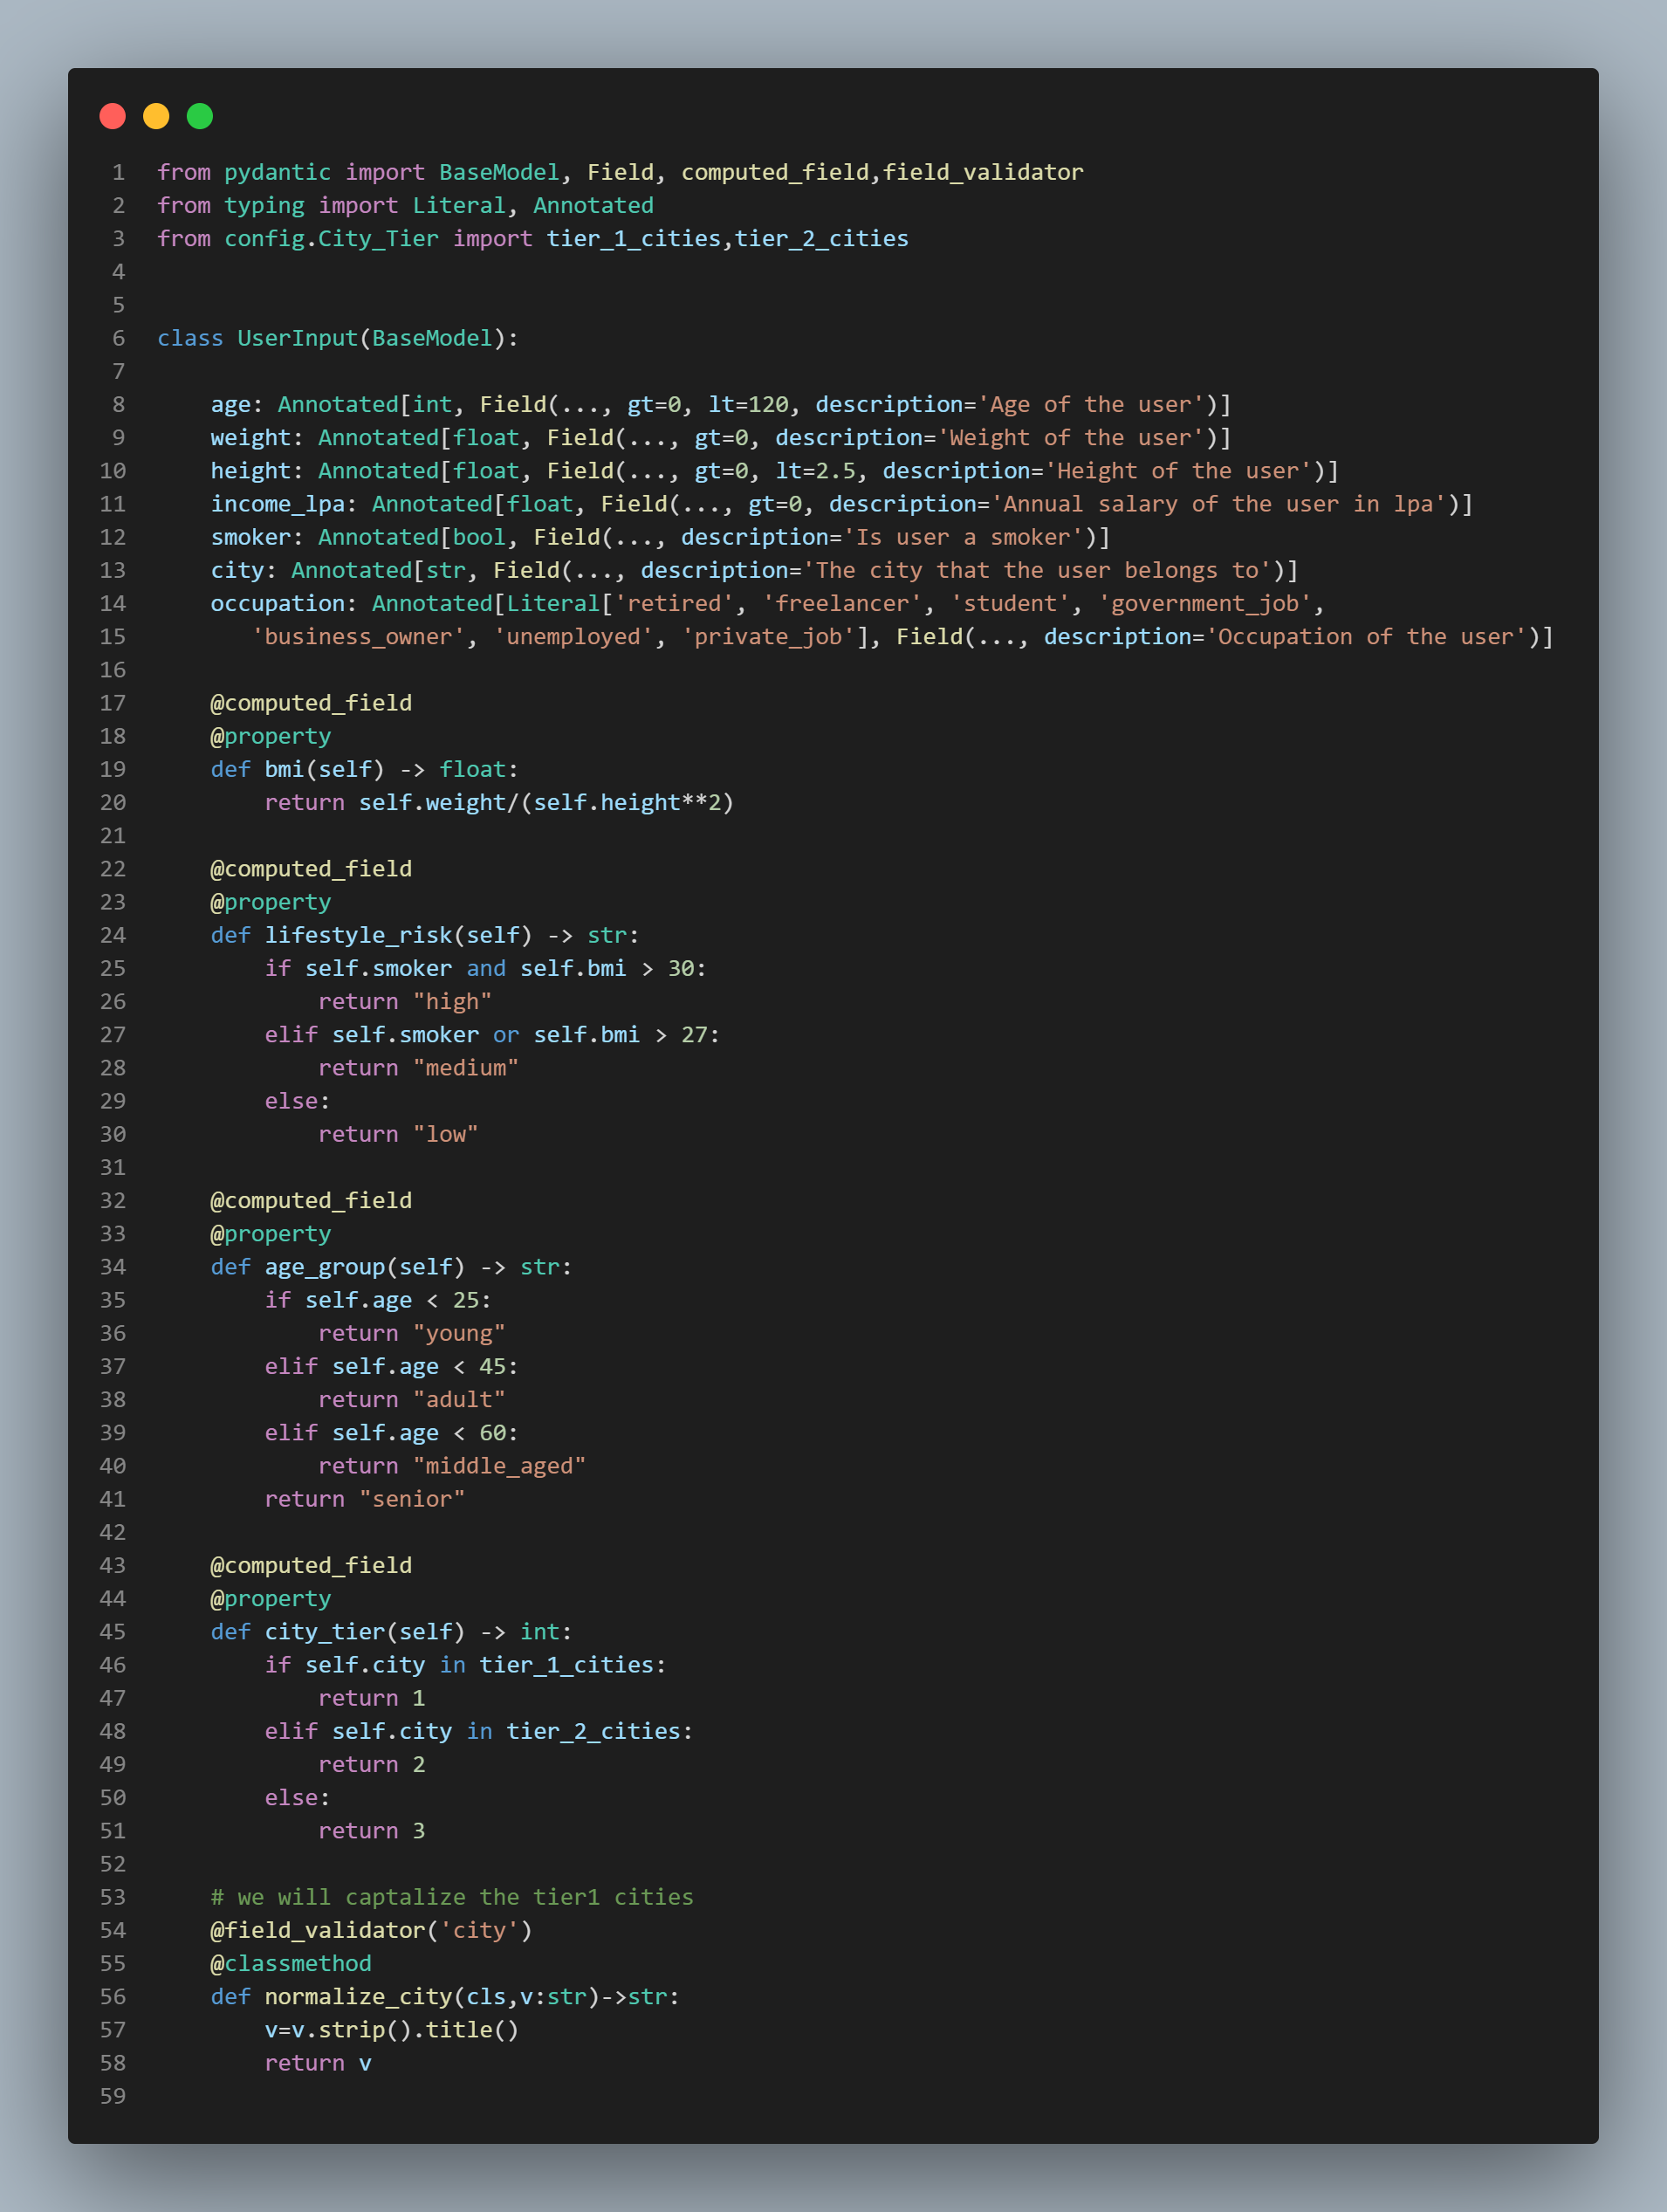

In [ ]:
# user_input.py

![image.png]()

<b>imrpovement5.2:-Seperate file for City Tier(City_Tier.py)


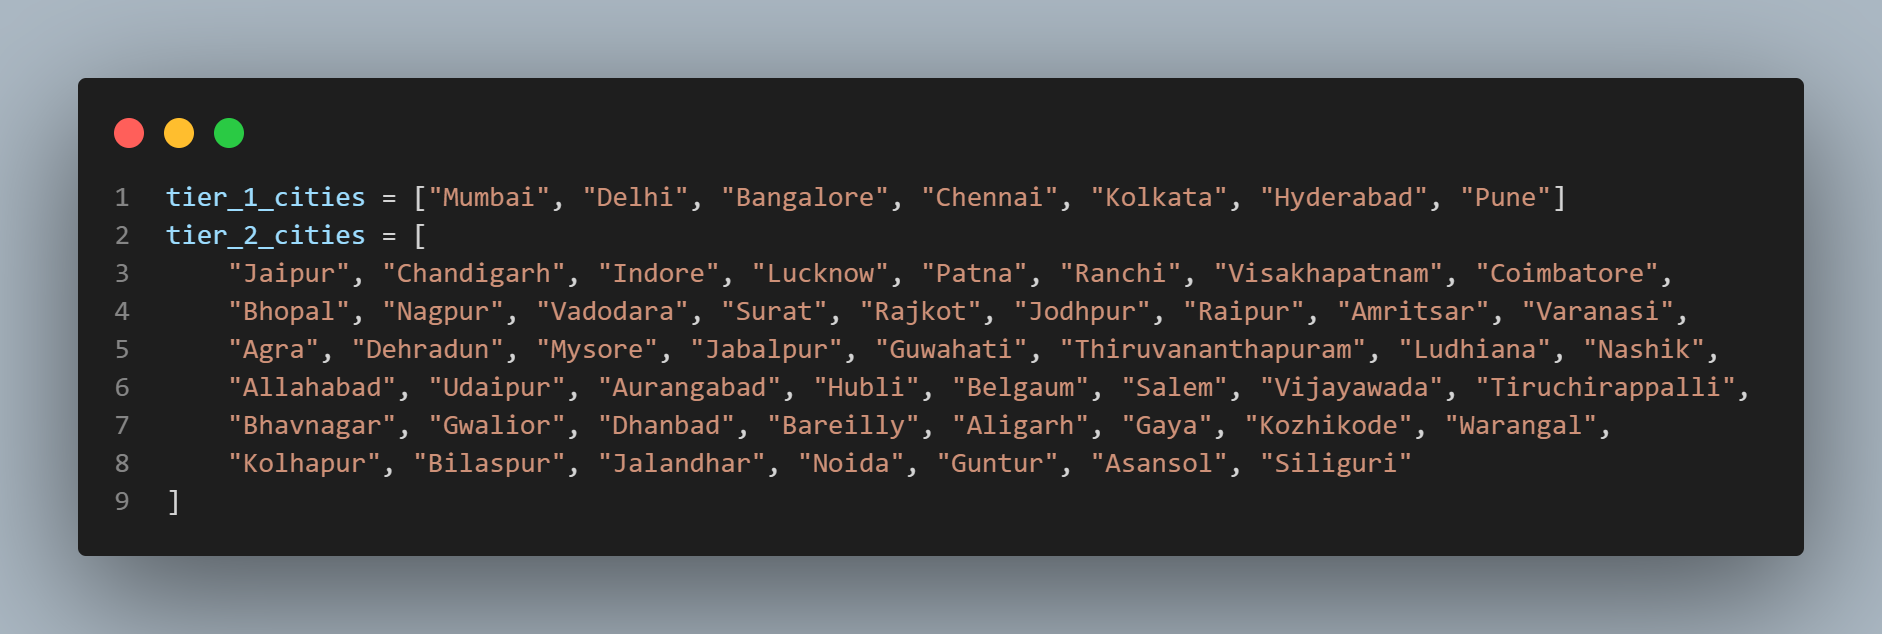

improvement5.3:-Seperate file for ML Logic(predict.py)

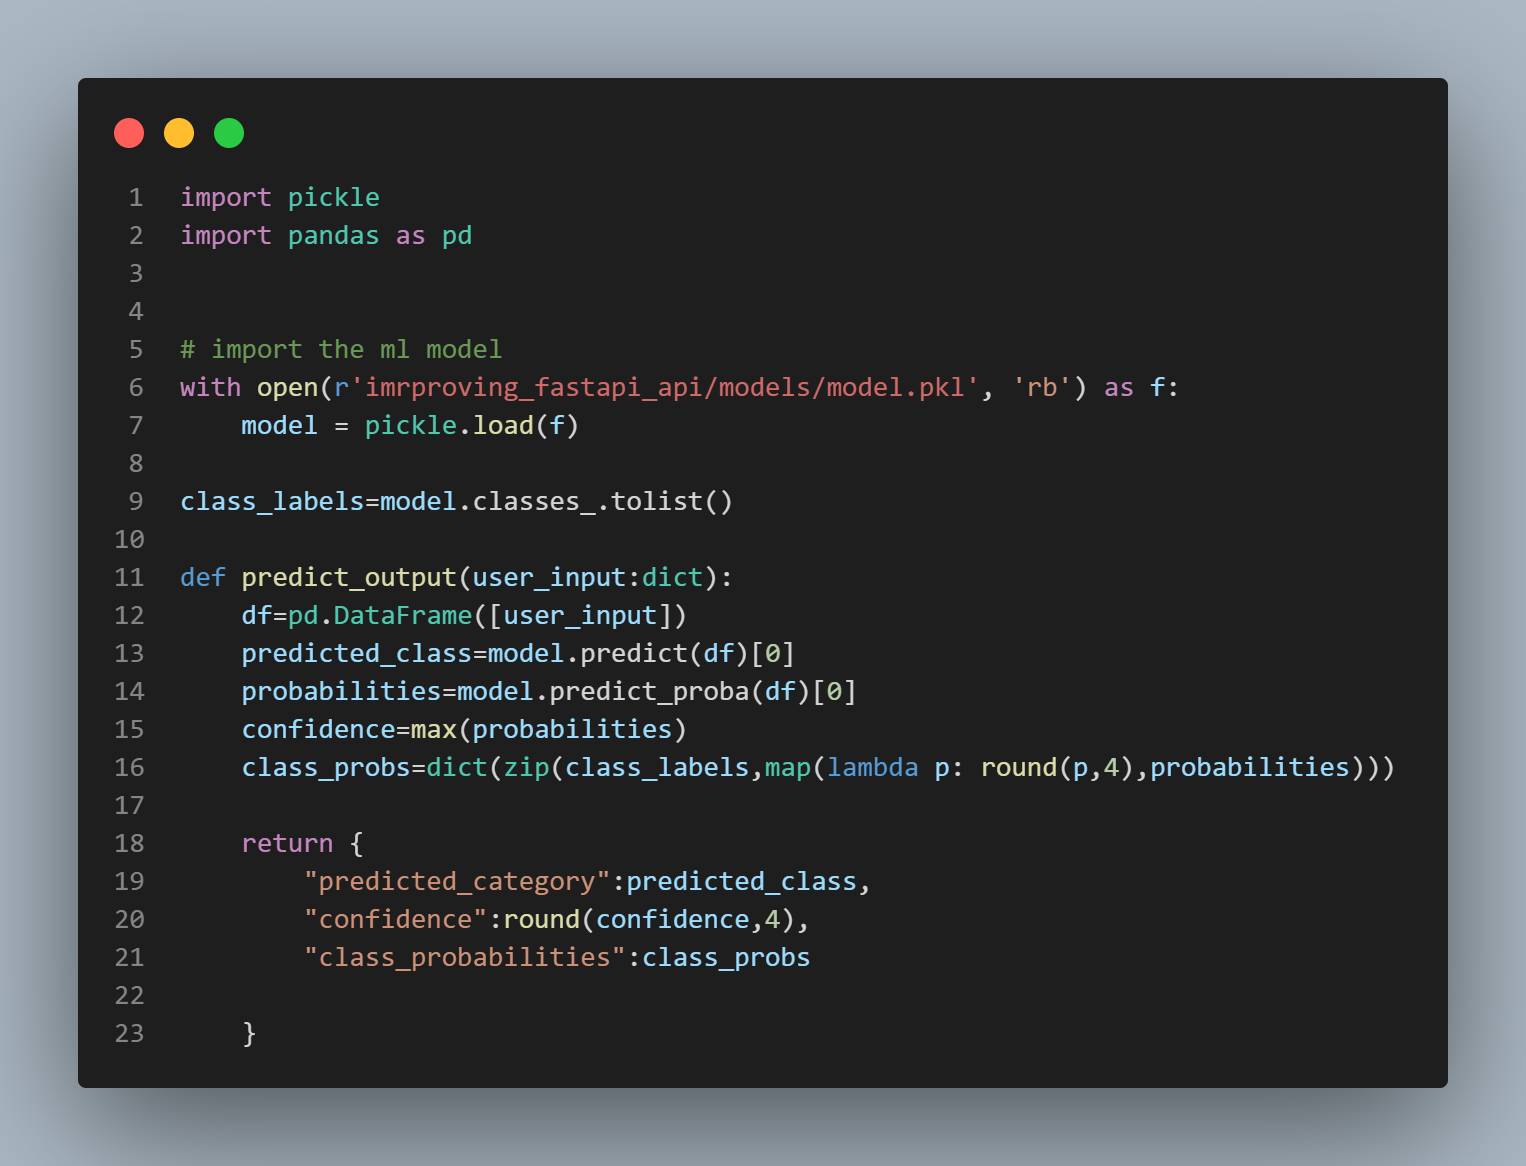

improvement5.4:-seperate fle for FastApi(app.py)

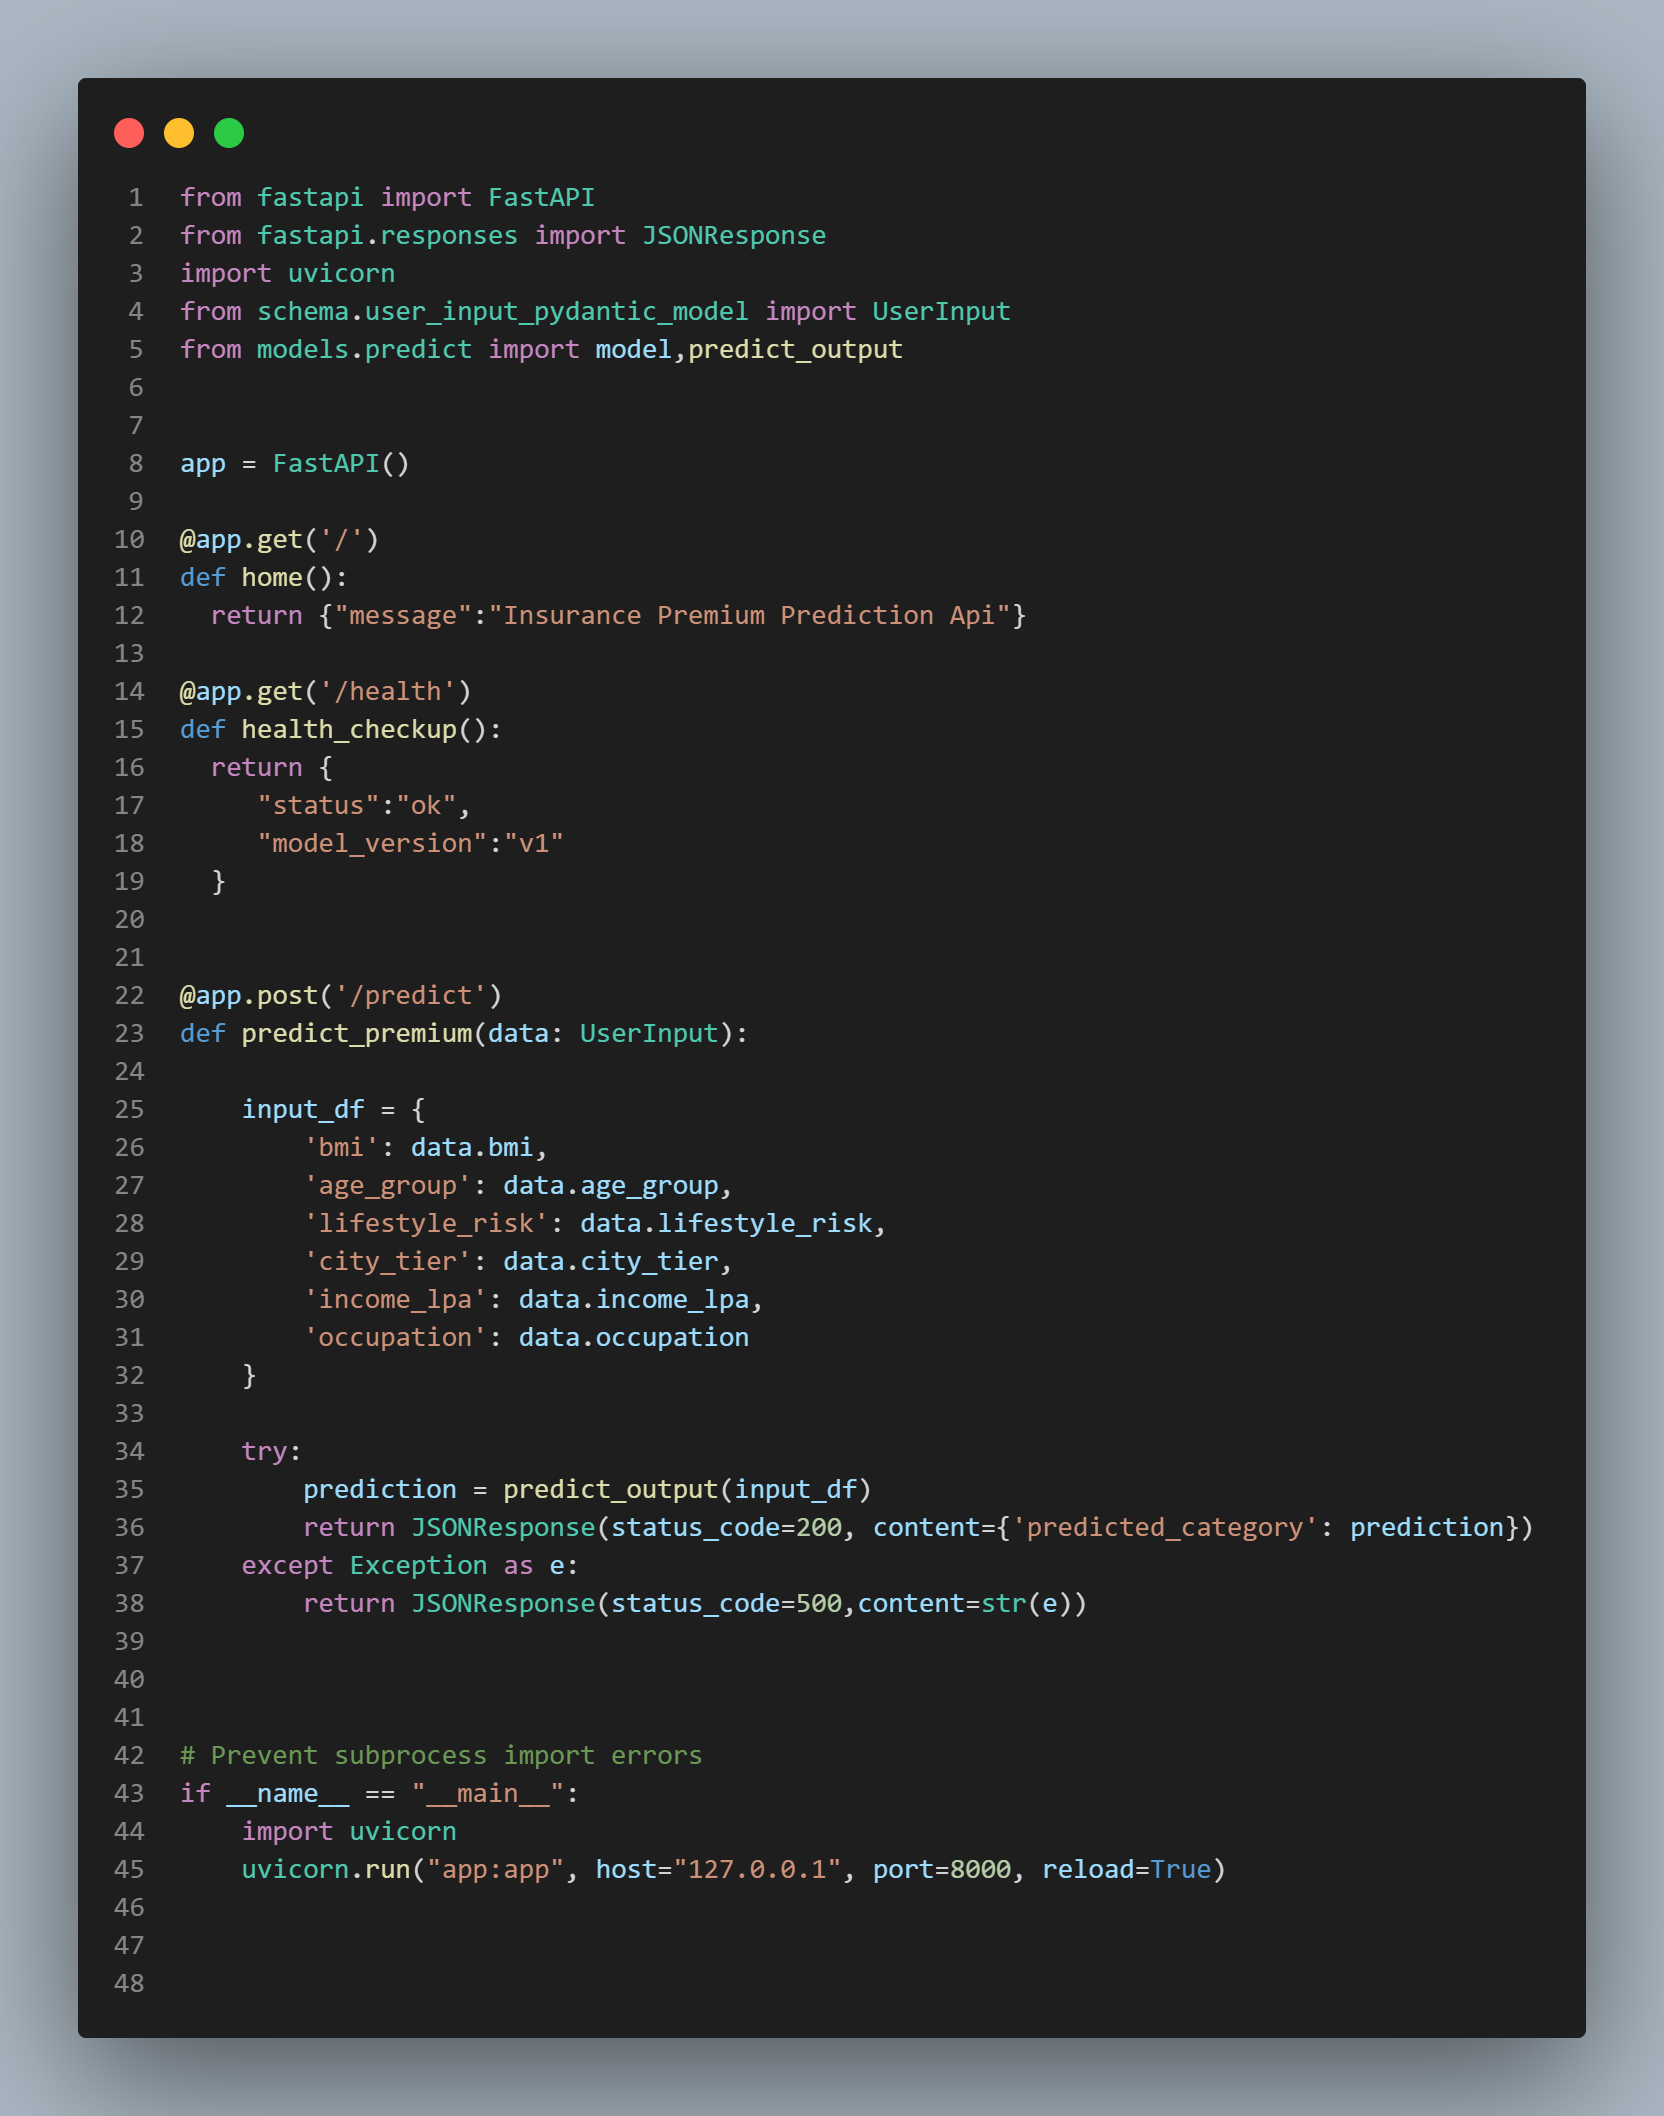